# Proyek Analisis Data: Bike-Sharing-Dataset
- **Nama:** Muhammad Omar Wylie
- **Email:** cdcc001d6y0082@student.devacademy.id
- **ID Dicoding:** 	CDCC001D6Y0082

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pola rata-rata jumlah penyewaan sepeda per jam berdasarkan tipe hari (hari kerja vs. hari libur/akhir pekan) selama tahun 2011–2012, dan pada jam berapa permintaan mencapai puncaknya?
  > *Analisis ini bersifat **Specific** (fokus pada pola per jam dan tipe hari), **Measurable** (rata-rata jumlah rental per jam), **Action-Oriented** (dapat digunakan untuk mengatur ketersediaan sepeda di jam-jam sibuk), **Relevant** (langsung memengaruhi efisiensi operasional), dan **Time-bound** (data tahun 2011–2012).*

- **Pertanyaan 2:** Bagaimana pengaruh musim (season) dan kondisi cuaca (weathersit) terhadap total penyewaan sepeda harian selama tahun 2011–2012, dan kombinasi mana yang menghasilkan permintaan tertinggi dan terendah?
  > *Analisis ini bersifat **Specific** (fokus pada variabel musim dan cuaca terhadap total rental harian), **Measurable** (rata-rata total penyewaan per kombinasi musim & cuaca), **Action-Oriented** (dapat digunakan untuk merancang strategi promosi dan pengelolaan armada sepeda), **Relevant** (musim dan cuaca adalah faktor eksternal penting dalam bisnis bike sharing), dan **Time-bound** (data tahun 2011–2012).*



## Import Semua Packages/Library yang Digunakan

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set global style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Libraries loaded success')

Libraries loaded success


## Data Wrangling

### Gathering Data

#### Load df ...

In [5]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- `day_df` berisi 731 baris (731 hari = 2 tahun) dan 16 kolom.
- `hour_df` berisi 17.379 baris dan 17 kolom (terdapat tambahan kolom `hr` untuk jam).
- Kolom target utama adalah `cnt` (total penyewaan = `casual` + `registered`).
- Nilai numerik seperti `temp`, `atemp`, `hum`, dan `windspeed` sudah dinormalisasi.

### Assessing Data

Pada tahap ini, kita akan mengevaluasi kualitas data dengan mencari permasalahan seperti:
1. Missing values
2. Duplicate data
3. Tipe data yang tidak sesuai
4. Inaccurate values (nilai yang tidak sesuai konteks)

#### Identifying ... problem

In [6]:
#Identifying Missing Values & Duplicate Data
print('=== day_df ===')
print('Missing values per kolom:')
print(day_df.isnull().sum())
print(f'\nJumlah baris duplikat: {day_df.duplicated().sum()}')
print('=== hour_df ===')
print('Missing values per kolom:')
print(hour_df.isnull().sum())
print(f'\nJumlah baris duplikat: {hour_df.duplicated().sum()}')

#### Identifying Incorrect Data Types
print('=== Tipe data day_df ===')
print(day_df.dtypes)
print()
print('=== Tipe data hour_df ===')
print(hour_df.dtypes)

#### Identifying Inaccurate Values
print('=== Statistik Deskriptif day_df ===')
day_df[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].describe()
print('Hari dengan hum = 0:')
print(day_df[day_df['hum'] == 0][['dteday', 'hum', 'weathersit', 'cnt']])

=== day_df ===
Missing values per kolom:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah baris duplikat: 0
=== hour_df ===
Missing values per kolom:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah baris duplikat: 0
=== Tipe data day_df ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64


**Steps to Take:**

a. Identifying Missing Values & Duplicate Data
- Tidak ada missing values maupun duplikat pada kedua DataFrame.

b. Identifying Incorrect Data Types
- Konversi kolom `dteday` dari `object` ke `datetime64`.
- Peta nilai kolom `season`, `weathersit`, `weekday`, `mnth`, dan `yr` ke label yang deskriptif, lalu konversi ke tipe `category`.


c. Identifying Inaccurate Values
- Ganti nilai `hum` = 0 dengan nilai median dari kolom `hum`.

**Insight:** (Opsional)

a. Identifying Incorrect Data Types
- Kolom `dteday` bertipe `object` (string), seharusnya bertipe `datetime`.
- Kolom kategorikal seperti `season`, `mnth`, `weekday`, `weathersit`, `holiday`, `workingday`, dan `yr` bertipe `int64`, padahal secara semantik merupakan kategori. Perlu dikonversi ke tipe yang sesuai dan nilai numeriknya perlu dipetakan ke label yang lebih mudah dibaca.

b.Identifying Inaccurate Values
- Terdapat 1 baris dengan nilai `hum` (kelembaban) = 0, yang tidak realistis secara fisik. Nilai kelembaban 0% tidak mungkin terjadi di lingkungan terbuka.
- Nilai ini akan diisi dengan median kelembaban keseluruhan sebagai solusi yang konservatif.


### Cleaning Data

#### Fixing ... problem

In [7]:
#fixing incorect data type day_df
season_map    = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map   = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
weekday_map   = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
                 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
month_map     = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                 7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
yr_map        = {0: 2011, 1: 2012}

def clean_df(df):
    df = df.copy()
    df['dteday']    = pd.to_datetime(df['dteday'])
    df['season']    = df['season'].map(season_map).astype('category')
    df['weathersit']= df['weathersit'].map(weather_map).astype('category')
    df['weekday']   = df['weekday'].map(weekday_map).astype('category')
    df['mnth']      = df['mnth'].map(month_map).astype('category')
    df['yr']        = df['yr'].map(yr_map)
    df['holiday']   = df['holiday'].astype('category')
    df['workingday']= df['workingday'].astype('category')
    return df

day_df  = clean_df(day_df)
hour_df = clean_df(hour_df)

print('Tipe data day_df setelah cleaning:')
print(day_df.dtypes)

#Fixing Inaccurate Values — hum = 0
median_hum = day_df['hum'].median()
day_df.loc[day_df['hum'] == 0, 'hum'] = median_hum

print(f'Nilai median hum yang digunakan: {median_hum:.4f}')
print(f'Jumlah baris dengan hum = 0 setelah cleaning: {(day_df["hum"] == 0).sum()}')

#verifikasi hasil celaning
print('=== day_df setelah cleaning ===')
print(f'Shape: {day_df.shape}')
print(f'Missing values: {day_df.isnull().sum().sum()}')
print(f'Duplicates: {day_df.duplicated().sum()}')
day_df.head(3)

Tipe data day_df setelah cleaning:
instant                int64
dteday        datetime64[ns]
season              category
yr                     int64
mnth                category
holiday             category
weekday             category
workingday          category
weathersit          category
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object
Nilai median hum yang digunakan: 0.6267
Jumlah baris dengan hum = 0 setelah cleaning: 0
=== day_df setelah cleaning ===
Shape: (731, 16)
Missing values: 0
Duplicates: 0


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,Jan,0,Saturday,0,Mist/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,Jan,0,Sunday,0,Mist/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,Jan,0,Monday,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349


**Insight:** (Opsional)
- Seluruh tipe data telah diperbaiki: `dteday` kini bertipe `datetime64`, dan kolom kategorikal memiliki label yang lebih deskriptif.
- Satu nilai `hum` = 0 yang tidak realistis telah diganti dengan nilai median.
- Data siap untuk dianalisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore ...

In [8]:
#explore pertanyaan 1 :Explore pola penyewaan per jam berdasarkan tipe hari

#Rata-rata penyewaan per jam berdasarkan tipe hari
hourly_pattern = (
    hour_df.groupby(['hr', 'workingday'], observed=True)['cnt']
    .mean()
    .reset_index()
)
hourly_pattern['workingday'] = hourly_pattern['workingday'].map({1: 'Hari Kerja', 0: 'Hari Libur/Akhir Pekan'})

#jam puncak
peak_workday    = hourly_pattern[hourly_pattern['workingday']=='Hari Kerja'].nlargest(3, 'cnt')
peak_holiday    = hourly_pattern[hourly_pattern['workingday']=='Hari Libur/Akhir Pekan'].nlargest(3, 'cnt')

print('=== TOP 3 Jam Puncak - Hari Kerja ===')
print(peak_workday[['hr','cnt']].rename(columns={'hr':'Jam','cnt':'Rata-rata Penyewaan'}).to_string(index=False))

print('\n=== TOP 3 Jam Puncak - Hari Libur/Akhir Pekan ===')
print(peak_holiday[['hr','cnt']].rename(columns={'hr':'Jam','cnt':'Rata-rata Penyewaan'}).to_string(index=False))

# Statistik deskriptif per tipe hari
hour_df['day_type'] = hour_df['workingday'].map({1: 'Hari Kerja', 0: 'Hari Libur/Akhir Pekan'})
print('=== Statistik Rata-rata cnt per Tipe Hari ===')
print(hour_df.groupby('day_type')['cnt'].describe().round(2))

=== TOP 3 Jam Puncak - Hari Kerja ===
 Jam  Rata-rata Penyewaan
  17           525.290581
  18           492.226908
   8           477.006048

=== TOP 3 Jam Puncak - Hari Libur/Akhir Pekan ===
 Jam  Rata-rata Penyewaan
  13           372.731602
  12           366.259740
  14           364.645022
=== Statistik Rata-rata cnt per Tipe Hari ===
                          count    mean     std  min   25%    50%    75%  \
day_type                                                                   
Hari Libur/Akhir Pekan   5514.0  181.41  172.85  1.0  40.0  119.0  292.0   
Hari Kerja              11865.0  193.21  185.11  1.0  40.0  151.0  277.0   

                          max  
day_type                       
Hari Libur/Akhir Pekan  783.0  
Hari Kerja              977.0  


Insight:
- Pada **hari kerja**, terdapat dua puncak permintaan: sekitar pukul **08:00** (rush hour pagi) dan **17:00–18:00** (rush hour sore), yang menunjukkan pola komuter.
- Pada **hari libur/akhir pekan**, permintaan lebih tersebar merata sepanjang siang hari (pukul 11:00–15:00), menunjukkan pola penggunaan rekreasional.
- Pola ini memberikan informasi penting untuk penjadwalan ketersediaan sepeda.

In [9]:
#explore pertanyaan 2: Pengaruh musim&cuaca terhadap penyewaan harian

# Rata-rata penyewaan per musim
season_stats = (
    day_df.groupby('season', observed=True)['cnt']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
    .sort_values('mean', ascending=False)
)
print('=== Rata-rata Penyewaan Harian per Musim ===')
print(season_stats)

# Rata-rata penyewaan per kondisi cuaca
weather_stats = (
    day_df.groupby('weathersit', observed=True)['cnt']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
    .sort_values('mean', ascending=False)
)
print('=== Rata-rata Penyewaan Harian per Kondisi Cuaca ===')
print(weather_stats)

# Rata-rata penyewaan berdasarkan kombinasi musim & cuaca
season_weather = (
    day_df.groupby(['season', 'weathersit'], observed=True)['cnt']
    .mean()
    .round(0)
    .reset_index()
    .sort_values('cnt', ascending=False)
)
print('=== Kombinasi Musim & Cuaca (Top 5 vs Bottom 5) ===')
print('Top 5:')
print(season_weather.head())
print('\nBottom 5:')
print(season_weather.tail())

=== Rata-rata Penyewaan Harian per Musim ===
           mean  median      std  count
season                                 
Fall    5644.30  5353.5  1459.80    188
Summer  4992.33  4941.5  1695.98    184
Winter  4728.16  4634.5  1699.62    178
Spring  2604.13  2209.0  1399.94    181
=== Rata-rata Penyewaan Harian per Kondisi Cuaca ===
                    mean  median      std  count
weathersit                                      
Clear            4876.79  4844.0  1879.48    463
Mist/Cloudy      4035.86  4040.0  1809.11    247
Light Rain/Snow  1803.29  1817.0  1240.28     21
=== Kombinasi Musim & Cuaca (Top 5 vs Bottom 5) ===
Top 5:
    season   weathersit     cnt
0     Fall        Clear  5878.0
6   Summer        Clear  5549.0
2     Fall  Mist/Cloudy  5222.0
9   Winter        Clear  5044.0
11  Winter  Mist/Cloudy  4654.0

Bottom 5:
    season       weathersit     cnt
1     Fall  Light Rain/Snow  2752.0
5   Spring      Mist/Cloudy  2357.0
10  Winter  Light Rain/Snow  1962.0
7   Summer 

**Insight:** (Opsional)
- **Musim gugur (Fall)** mencatat rata-rata penyewaan harian tertinggi, diikuti musim panas (Summer). Musim semi (Spring) mencatat yang terendah.
- **Cuaca cerah (Clear)** secara konsisten menghasilkan penyewaan tertinggi, sementara hujan/salju lebat (Heavy Rain/Snow) paling rendah.
- Kombinasi terbaik adalah **Fall + Clear**, sedangkan kombinasi terburuk adalah kondisi cuaca ekstrem di musim apa pun.
- Penurunan tajam terlihat saat cuaca berubah dari Clear ke Light Rain/Snow, menunjukkan sensitivitas tinggi pengguna terhadap cuaca buruk.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pola penyewaan Per Jam Berdasarkan Tipe Hari

In [10]:
import os
os.makedirs('dashboard', exist_ok=True)

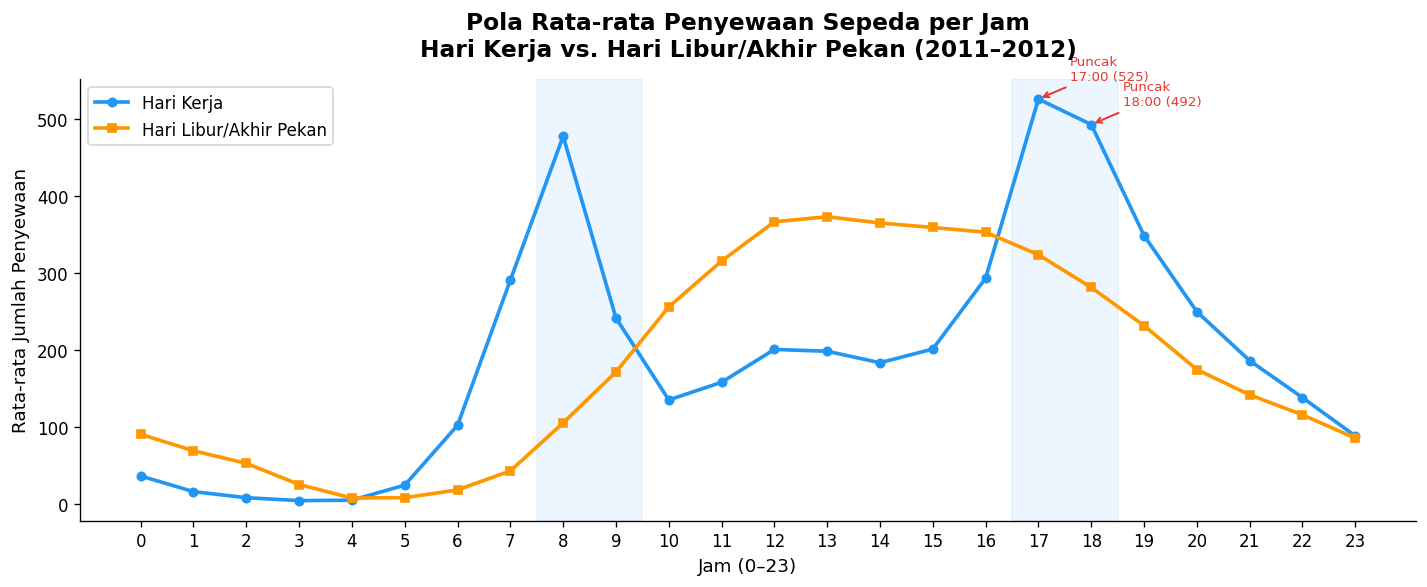

In [11]:
# Palette & Data
COLOR_WORKDAY  = '#2196F3'   # biru
COLOR_HOLIDAY  = '#FF9800'   # oranye
COLOR_PEAK     = '#E53935'   # merah (anotasi puncak)

work_data    = hourly_pattern[hourly_pattern['workingday'] == 'Hari Kerja']
holiday_data = hourly_pattern[hourly_pattern['workingday'] == 'Hari Libur/Akhir Pekan']

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(work_data['hr'], work_data['cnt'],
        marker='o', markersize=5, linewidth=2.2, color=COLOR_WORKDAY, label='Hari Kerja')
ax.plot(holiday_data['hr'], holiday_data['cnt'],
        marker='s', markersize=5, linewidth=2.2, color=COLOR_HOLIDAY, label='Hari Libur/Akhir Pekan')

# Anotasi jam puncak hari kerja
for _, row in peak_workday.head(2).iterrows():
    ax.annotate(
        f'Puncak\n{int(row["hr"]):02d}:00 ({row["cnt"]:.0f})',
        xy=(row['hr'], row['cnt']),
        xytext=(row['hr'] + 0.6, row['cnt'] + 25),
        fontsize=8, color=COLOR_PEAK,
        arrowprops=dict(arrowstyle='->', color=COLOR_PEAK, lw=1.2)
    )

ax.set_title('Pola Rata-rata Penyewaan Sepeda per Jam\nHari Kerja vs. Hari Libur/Akhir Pekan (2011–2012)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Jam (0–23)', fontsize=11)
ax.set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=11)
ax.set_xticks(range(0, 24))
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Shade jam sibuk
ax.axvspan(7.5, 9.5, alpha=0.08, color=COLOR_WORKDAY)
ax.axvspan(16.5, 18.5, alpha=0.08, color=COLOR_WORKDAY)

plt.tight_layout()
plt.savefig('dashboard/hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

Insight:
- Pada **hari kerja**, permintaan membentuk pola bimodal (dua puncak): pukul **08:00** dan **17:00–18:00**, mencerminkan perilaku komuter yang menggunakan sepeda untuk perjalanan berangkat dan pulang kerja.
- Pada **hari libur/akhir pekan**, permintaan meningkat secara gradual dari pagi dan mencapai puncak di siang hari (pukul **12:00–14:00**), mencerminkan aktivitas rekreasional.
- Zona abu-abu menandai jam sibuk hari kerja — di sinilah ketersediaan sepeda perlu dijaga paling optimal.


### Pertanyaan 2:Pengaruh Musim dan Cuaca Terhadap Penyewaan Harian

In [12]:
print(day_df['season'].value_counts())
print()
print(day_df['season'].dtype)
print()
print(day_df[['season', 'cnt']].head())

season
Fall      188
Summer    184
Spring    181
Winter    178
Name: count, dtype: int64

category

   season   cnt
0  Spring   985
1  Spring   801
2  Spring  1349
3  Spring  1562
4  Spring  1600


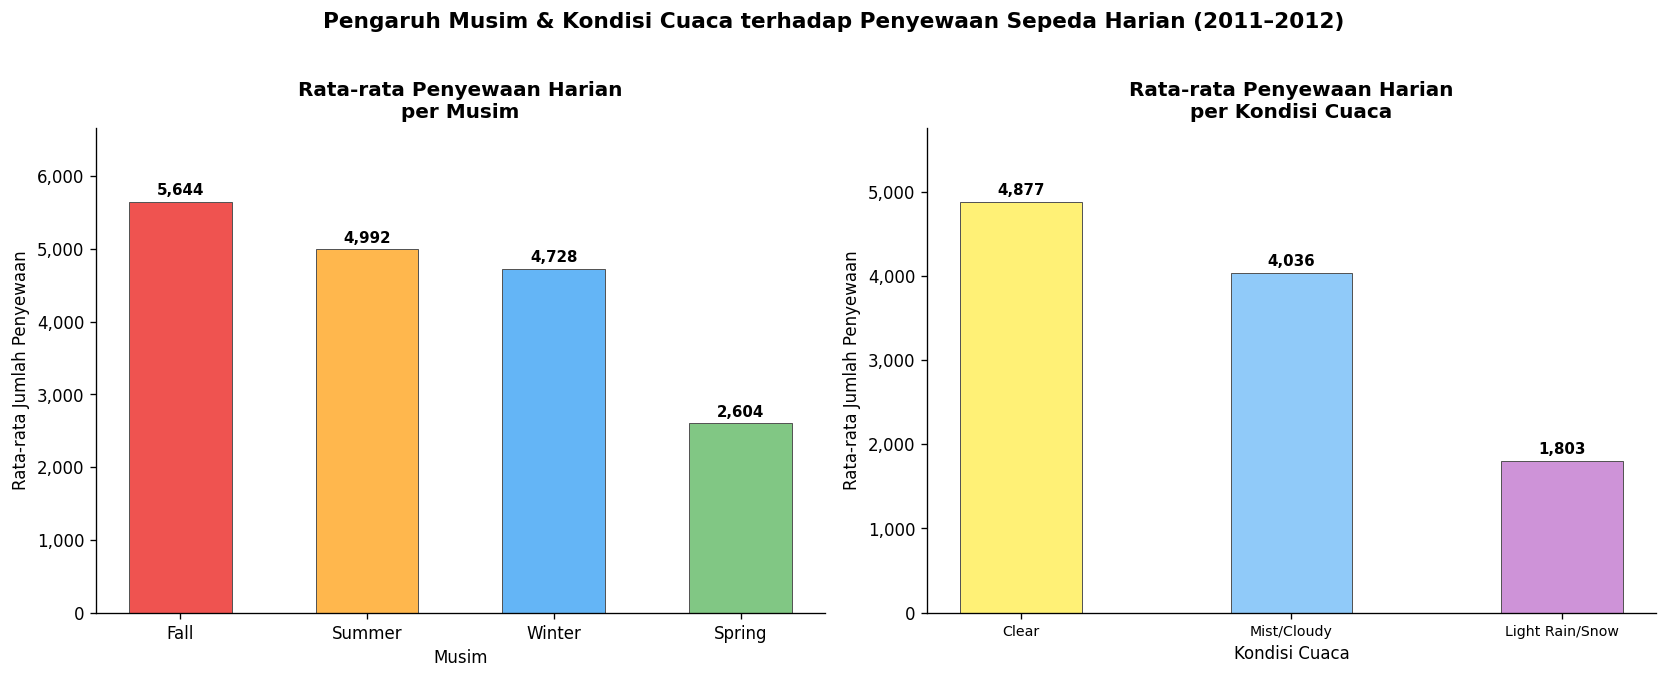

In [13]:
season_agg = day_df.groupby('season', observed=True)['cnt'].mean().sort_values(ascending=False)
weather_agg = day_df.groupby('weathersit', observed=True)['cnt'].mean().sort_values(ascending=False)

# --- Palette ---
SEASON_COLORS = {
    'Spring': '#81C784', 'Summer': '#FFB74D',
    'Fall': '#EF5350',   'Winter': '#64B5F6'
}
WEATHER_COLORS = {
    'Clear': '#FFF176', 'Mist/Cloudy': '#90CAF9',
    'Light Rain/Snow': '#CE93D8'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ---- Panel kiri ----
bars_s = axes[0].bar(
    season_agg.index, season_agg.values,
    color=[SEASON_COLORS.get(s, '#90A4AE') for s in season_agg.index],
    edgecolor='#555', linewidth=0.6, width=0.55
)
for bar in bars_s:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{bar.get_height():,.0f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_title('Rata-rata Penyewaan Harian\nper Musim', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Musim', fontsize=10)
axes[0].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].set_ylim(0, season_agg.max() * 1.18)

# ---- Panel kanan ----
bars_w = axes[1].bar(
    weather_agg.index, weather_agg.values,
    color=[WEATHER_COLORS.get(w, '#BDBDBD') for w in weather_agg.index],
    edgecolor='#555', linewidth=0.6, width=0.45
)
for bar in bars_w:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{bar.get_height():,.0f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_title('Rata-rata Penyewaan Harian\nper Kondisi Cuaca', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca', fontsize=10)
axes[1].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[1].set_ylim(0, weather_agg.max() * 1.18)
axes[1].tick_params(axis='x', labelsize=8.5)

fig.suptitle('Pengaruh Musim & Kondisi Cuaca terhadap Penyewaan Sepeda Harian (2011–2012)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('dashboard/season_weather.png', dpi=150, bbox_inches='tight')
plt.show()

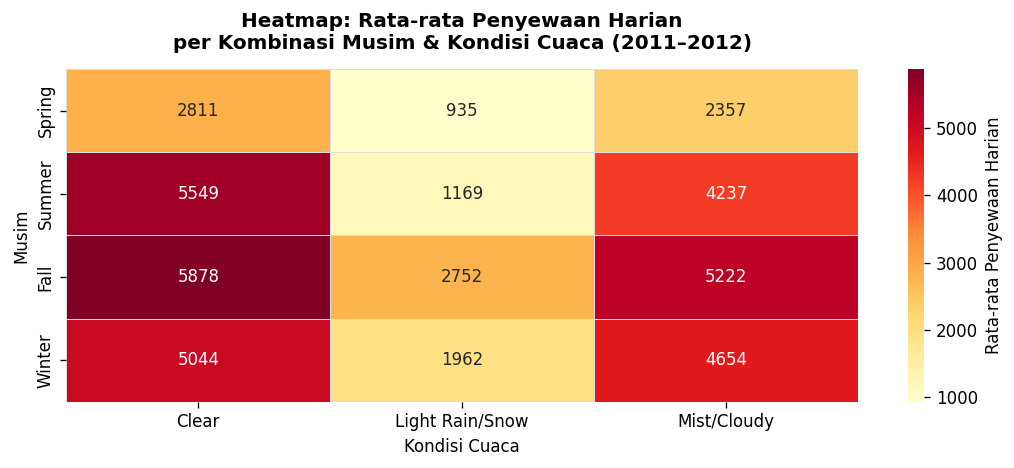

In [14]:
# Heatmap: Rata-rata penyewaan per kombinasi musim & cuaca
heatmap_data = (
    day_df.groupby(['season', 'weathersit'], observed=True)['cnt']
    .mean()
    .round(0)
    .unstack(level='weathersit')
)
# Urutkan musim sesuai kalender
season_order_cal = ['Spring', 'Summer', 'Fall', 'Winter']
heatmap_data = heatmap_data.reindex(season_order_cal)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, linecolor='#ddd',
    cbar_kws={'label': 'Rata-rata Penyewaan Harian'},
    ax=ax
)
ax.set_title('Heatmap: Rata-rata Penyewaan Harian\nper Kombinasi Musim & Kondisi Cuaca (2011–2012)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Kondisi Cuaca', fontsize=10)
ax.set_ylabel('Musim', fontsize=10)
plt.tight_layout()
plt.savefig('dashboard/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** (Opsional)
- **Musim gugur (Fall) + Cuaca Cerah (Clear)** adalah kombinasi dengan rata-rata penyewaan harian tertinggi (>5.000 unit/hari).
- **Musim semi (Spring)** secara konsisten mencatat penyewaan paling rendah dibandingkan musim lain, mungkin karena cuaca yang masih belum stabil.
- Penurunan penyewaan akibat cuaca buruk sangat signifikan: cuaca **Light Rain/Snow** dapat memangkas permintaan hingga >40% dibandingkan cuaca cerah pada musim yang sama.
- Heatmap menunjukkan tidak ada data **Heavy Rain/Snow** yang cukup signifikan di sebagian besar musim, mengindikasikan kondisi tersebut sangat jarang terjadi.

In [15]:
day_df.to_csv('main_data.csv', index=False)
hour_df.to_csv('hour_data.csv', index=False)

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Pola penyewaan sepeda per jam sangat dipengaruhi oleh tipe hari. Pada hari kerja, permintaan membentuk pola bimodal dengan dua puncak di jam **08:00** dan **17:00–18:00**, mencerminkan penggunaan sepeda sebagai alat transportasi komuter. Sebaliknya, pada hari libur/akhir pekan, permintaan menyebar merata di siang hari (pukul 11:00–15:00) yang mencerminkan penggunaan rekreasional. Perbedaan pola ini menunjukkan bahwa perilaku pengguna terdiri dari dua segmen yang berbeda: **komuter** dan **pengguna rekreasional**.

- **Conclusion pertanyaan 2:** Musim dan kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan harian. **Musim gugur (Fall)** menghasilkan rata-rata penyewaan harian tertinggi, diikuti musim panas (Summer), musim dingin (Winter), dan musim semi (Spring). Kondisi **cuaca cerah** secara konsisten meningkatkan penyewaan, sementara cuaca hujan/bersalju dapat memangkas permintaan hingga lebih dari 40%. Kombinasi **Fall + Clear** adalah skenario permintaan tertinggi.


**Rekomendasi Action Item:**
- **Manajemen Armada Dinamis:** Tambah ketersediaan sepeda di stasiun-stasiun strategis pada pukul **07:00–09:00** dan **16:00–19:00** di hari kerja untuk mengantisipasi lonjakan permintaan komuter. Di hari libur, distribusikan sepeda ke area rekreasional mulai pukul **10:00**.
- **Strategi Promosi Berbasis Musim:** Fokuskan kampanye promosi dan program loyalitas pada periode **musim gugur dan panas** untuk memaksimalkan pendapatan. Tawarkan insentif atau diskon khusus di **musim semi** dan hari-hari dengan cuaca buruk untuk merangsang permintaan di periode rendah.
- **Perencanaan Pemeliharaan:** Jadwalkan pemeliharaan armada sepeda pada jam-jam sepi (dini hari, pukul 01:00–05:00) dan di bulan-bulan musim semi yang memiliki permintaan terendah, sehingga tidak mengganggu operasional di jam dan musim puncak.